# PERANCANGAN DAN ANALISIS ALGORITMA
### Sistem Peramalan Pengadaan Stok Multi-Obat Menggunakan Metode Double Exponential Smoothing (Holt)

---

## Cell 1: Import Library dan Pengaturan Grafik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Mengatur gaya grafik agar rapi dan scannable
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 6)
print("Library berhasil dimuat.")

Library berhasil dimuat.


## Cell 2: Membaca Dataset Mentah & Pembersihan Header
Memotong baris bertingkat menggunakan `iloc[2:]` agar data obat pertama (Amlodipine) tidak ikut terbuang.

In [2]:
# 1. Membaca file Excel secara mentah
df_raw = pd.read_excel('data_set.xlsx')

# 2. Potong dari indeks ke-2 agar obat pertama (Amlodipine) tidak ikut terpotong
df = df_raw.iloc[2:].copy()

# 3. Merapikan nama kolom identitas utama sesuai dengan cell Excel
df.rename(columns={
    'No': 'No',
    'No Obat': 'Kode Rak/Lokasi',
    'Kode Obat': 'Nama Obat',
    'Golongan': 'Golongan Obat'
}, inplace=True)

print("Jumlah Data Obat (Baris) :", df.shape[0])
print("Jumlah Kolom Data        :", df.shape[1])

# Menampilkan 5 data obat teratas
df.head()

Jumlah Data Obat (Baris) : 10
Jumlah Kolom Data        : 41


,No,Kode Rak/Lokasi,Nama Obat,Golongan Obat,Satuan,Tahun,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40
2,1.0,OBT-001,Amlodipine 5mg,Obat Keras (Hipertensi),Tablet,1000,1020,1050,1030,1060,...,1340,1390,1410,1450,1430,1470,1500,1480,1520,1560
3,2.0,OBT-002,Metformin 500mg,Obat Keras (Diabetes),Tablet,800,810,790,805,820,...,850,865,870,860,875,880,865,885,890,880
4,3.0,OBT-003,Paracetamol 500mg,Obat Bebas (Demam),Tablet,1500,1420,1650,1300,1250,...,1800,1450,1400,2100,1900,1700,1550,2250,2450,1850
5,4.0,OBT-004,Amoxicillin 500mg,Obat Keras (Antibiotik),Tablet,600,580,620,590,610,...,700,660,680,720,690,700,730,710,750,720
6,5.0,OBT-005,Cefadroxil 500mg,Obat Keras (Antibiotik),Kapsul,400,410,395,420,405,...,480,520,505,530,515,525,540,535,560,575


## Cell 3: Informasi Struktur Dataset
Mengecek tipe data dari kolom-kolom yang tersedia.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 2 to 11
Data columns (total 41 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   No               10 non-null     float64
 1   Kode Rak/Lokasi  10 non-null     str    
 2   Nama Obat        10 non-null     str    
 3   Golongan Obat    10 non-null     str    
 4   Satuan           10 non-null     str    
 5   Tahun            10 non-null     object 
 6   Unnamed: 6       10 non-null     object 
 7   Unnamed: 7       10 non-null     object 
 8   Unnamed: 8       10 non-null     object 
 9   Unnamed: 9       10 non-null     object 
 10  Unnamed: 10      10 non-null     object 
 11  Unnamed: 11      10 non-null     object 
 12  Unnamed: 12      10 non-null     object 
 13  Unnamed: 13      10 non-null     object 
 14  Unnamed: 14      10 non-null     object 
 15  Unnamed: 15      10 non-null     object 
 16  Unnamed: 16      10 non-null     object 
 17  Unnamed: 17      10 non-null 

## Cell 4: Statistik Deskriptif Data Obat
Menampilkan ringkasan statistik (mean, min, max, std) dari volume pemakaian obat.

In [4]:
display(df.describe())

,No
count,10.00000
mean,5.50000
std,3.02765
min,1.00000
25%,3.25000
50%,5.50000
75%,7.75000
max,10.00000


## Cell 5: Pemeriksaan Missing Value
Memastikan data obat dari baris 4 ke bawah bersih dan bernilai 0 (tidak ada data kosong).

In [5]:
print("====== PEMERIKSAAN MISSING VALUE PADA DATA OBAT ======")
df.isnull().sum()

====== PEMERIKSAAN MISSING VALUE PADA DATA OBAT ======


No                 0
Kode Rak/Lokasi    0
Nama Obat          0
Golongan Obat      0
Satuan             0
Tahun              0
Unnamed: 6         0
Unnamed: 7         0
Unnamed: 8         0
Unnamed: 9         0
Unnamed: 10        0
Unnamed: 11        0
Unnamed: 12        0
Unnamed: 13        0
Unnamed: 14        0
Unnamed: 15        0
Unnamed: 16        0
Unnamed: 17        0
Unnamed: 18        0
Unnamed: 19        0
Unnamed: 20        0
Unnamed: 21        0
Unnamed: 22        0
Unnamed: 23        0
Unnamed: 24        0
Unnamed: 25        0
Unnamed: 26        0
Unnamed: 27        0
Unnamed: 28        0
Unnamed: 29        0
Unnamed: 30        0
Unnamed: 31        0
Unnamed: 32        0
Unnamed: 33        0
Unnamed: 34        0
Unnamed: 35        0
Unnamed: 36        0
Unnamed: 37        0
Unnamed: 38        0
Unnamed: 39        0
Unnamed: 40        0
dtype: int64

## Cell 6: Ekstraksi Data (Wide ke Linear Time-Series)
Mengubah bentuk matriks 36 bulan dari kolom F sampai AO menjadi array satu dimensi tunggal untuk setiap obat.

In [6]:
df_data = df_raw.iloc[2:].copy()

# Mengambil daftar nama obat asli dari kolom 'Kode Obat'
obat_list = df_data['Kode Obat'].dropna().unique()
time_series_data = {}

# Angka 36 bulan berjejer dari Kolom F (indeks ke-5) s.d Kolom AO (indeks ke-40)
kolom_angka = df_raw.columns[5:41]

for obat in obat_list:
    df_obat = df_data[df_data['Kode Obat'] == obat]
    ts_values = df_obat[kolom_angka].values.flatten()
    time_series_data[obat] = np.array(ts_values[:36], dtype=float)

print(f"[SUKSES] Berhasil mengekstrak {len(time_series_data)} jenis obat secara utuh!")
print(f"Contoh Data Obat Pertama '{obat_list[0]}' (36 Bulan Linear):\n", time_series_data[obat_list[0]])

[SUKSES] Berhasil mengekstrak 10 jenis obat secara utuh!
Contoh Data Obat Pertama 'Amlodipine 5mg' (36 Bulan Linear):
 [1000. 1020. 1050. 1030. 1060. 1080. 1100. 1090. 1120. 1150. 1130. 1170.
 1150. 1180. 1160. 1200. 1220. 1250. 1240. 1270. 1300. 1290. 1320. 1350.
 1320. 1360. 1340. 1390. 1410. 1450. 1430. 1470. 1500. 1480. 1520. 1560.]


## Cell 7: Implementasi Algoritma Double Exponential Smoothing (Metode Holt)
Logika inti komputasi peramalan dengan dua parameter konstanta pemulusan (Alpha & Beta).

In [7]:
def holt_double_exponential_smoothing(data, alpha=0.4, beta=0.3):
    n = len(data)
    S = np.zeros(n)
    T = np.zeros(n)
    F = np.zeros(n + 1)

    # Inisialisasi awal level dan tren (Bulan 1)
    S[0] = data[0]
    T[0] = data[1] - data[0]
    F[1] = S[0] + T[0]

    # Perulangan Utama Iterasi Rumus Holt (O(N))
    for t in range(1, n):
        S[t] = alpha * data[t] + (1 - alpha) * (S[t-1] + T[t-1])
        T[t] = beta * (S[t] - S[t-1]) + (1 - beta) * T[t-1]
        F[t+1] = S[t] + T[t]

    return S, T, F

## Cell 8: Eksekusi Peramalan & Tabel Evaluasi Utama (MAPE)
Mengukur performa nilai galat algoritma menggunakan metode Mean Absolute Percentage Error (MAPE).

In [8]:
ALPHA = 0.4
BETA = 0.3
hasil_evaluasi = []
data_plot = {}

for obat, data_aktual in time_series_data.items():
    S, T, F = holt_double_exponential_smoothing(data_aktual, alpha=ALPHA, beta=BETA)
    
    aktual_2025 = data_aktual[24:36]
    prediksi_2025 = F[24:36]
    
    mape = np.mean(np.abs((aktual_2025 - prediksi_2025) / aktual_2025)) * 100
    
    hasil_evaluasi.append({
        'Nama Obat': obat,
        'Prediksi Stok (Januari 2026)': round(F[36]),
        'Nilai MAPE (%)': round(mape, 2)
    })
    
    data_plot[obat] = {'aktual': data_aktual, 'prediksi': F}

df_hasil = pd.DataFrame(hasil_evaluasi)
print("====== TABEL HASIL UTAMA PERAMALAN ALGORITMA HOLT ======")
display(df_hasil)

====== TABEL HASIL UTAMA PERAMALAN ALGORITMA HOLT ======


,Nama Obat,Prediksi Stok (Januari 2026),Nilai MAPE (%)
0,Amlodipine 5mg,1566,1.51
1,Metformin 500mg,888,0.92
2,Paracetamol 500mg,2169,17.87
3,Amoxicillin 500mg,741,2.81
4,Cefadroxil 500mg,573,2.39
5,Cetirizine 10mg,603,9.41
6,Omeprazole 20mg,1007,1.84
7,Simvastatin 20mg,803,1.27
8,Mefenamic Acid 500mg,1007,6.84
9,Antasida Doen,1266,2.01


## Cell 9: Perbandingan Nilai Aktual, Prediksi, dan Ramalan Januari 2026
Menggabungkan data uji tahun 2025 dengan hasil proyeksi masa depan untuk bulan Januari 2026 (Bulan ke-37).

In [10]:
list_perbandingan = []

for obat, data_aktual in time_series_data.items():
    _, _, F = holt_double_exponential_smoothing(data_aktual, alpha=ALPHA, beta=BETA)
    aktual_2025 = data_aktual[24:36]
    prediksi_2025 = F[24:36]
    
    # 1. Memasukkan data komparasi tahun 2025
    for bln in range(12):
        selisih = abs(aktual_2025[bln] - prediksi_2025[bln])
        list_perbandingan.append({
            'Nama Obat': obat,
            'Periode / Bulan': f"Bulan {25 + bln} (2025)",
            'Aktual': aktual_2025[bln],
            'Prediksi': round(prediksi_2025[bln], 2),
            'Selisih': round(selisih, 2),
            'Keterangan': 'Data Uji (Backtesting)'
        })
    
    # 2. Memasukkan baris proyeksi masa depan untuk Januari 2026 (Bulan ke-37)
    list_perbandingan.append({
        'Nama Obat': obat,
        'Periode / Bulan': 'Bulan 37 (Jan 2026)',
        'Aktual': np.nan,
        'Prediksi': round(F[36], 2),
        'Selisih': np.nan,
        'Keterangan': 'PERAMALAN MASA DEPAN'
    })

df_perbandingan = pd.DataFrame(list_perbandingan)
print("====== TABEL KOMPARASI DETIL DAN PROYEKSI JANUARI 2026 ======")
display(df_perbandingan.head(13))

====== TABEL KOMPARASI DETIL DAN PROYEKSI JANUARI 2026 ======


,Nama Obat,Periode / Bulan,Aktual,Prediksi,Selisih,Keterangan
0,Amlodipine 5mg,Bulan 25 (2025),1320.0,1359.40,39.40,Data Uji (Backtesting)
1,Amlodipine 5mg,Bulan 26 (2025),1360.0,1357.67,2.33,Data Uji (Backtesting)
2,Amlodipine 5mg,Bulan 27 (2025),1340.0,1372.91,32.91,Data Uji (Backtesting)
3,Amlodipine 5mg,Bulan 28 (2025),1390.0,1370.11,19.89,Data Uji (Backtesting)
4,Amlodipine 5mg,Bulan 29 (2025),1410.0,1390.81,19.19,Data Uji (Backtesting)
5,Amlodipine 5mg,Bulan 30 (2025),1450.0,1413.54,36.46,Data Uji (Backtesting)
6,Amlodipine 5mg,Bulan 31 (2025),1430.0,1447.55,17.55,Data Uji (Backtesting)
7,Amlodipine 5mg,Bulan 32 (2025),1470.0,1457.85,12.15,Data Uji (Backtesting)
8,Amlodipine 5mg,Bulan 33 (2025),1500.0,1481.49,18.51,Data Uji (Backtesting)
9,Amlodipine 5mg,Bulan 34 (2025),1480.0,1509.89,29.89,Data Uji (Backtesting)


## Cell 10: Validasi Prediksi Berdasarkan Batas Toleransi
Mengukur kelayakan hasil peramalan dengan batas toleransi selisih galat sebesar 50 unit obat.

In [11]:
toleransi_obat = 50.0

kondisi_validasi = [
    (df_perbandingan['Keterangan'] == 'PERAMALAN MASA DEPAN'),
    (df_perbandingan['Selisih'] <= toleransi_obat),
    (df_perbandingan['Selisih'] > toleransi_obat)
]
pilihan_status = ["- (Belum Terjadi)", "✓ Sesuai", "✗ Tidak Sesuai"]

df_perbandingan['Validasi'] = np.select(kondisi_validasi, pilihan_status, default="-")

print("====== TABEL VALIDASI TOLERANSI PREDIKSI OBAT ======")
display(df_perbandingan.head(13))

====== TABEL VALIDASI TOLERANSI PREDIKSI OBAT ======


,Nama Obat,Periode / Bulan,Aktual,Prediksi,Selisih,Keterangan,Validasi
0,Amlodipine 5mg,Bulan 25 (2025),1320.0,1359.40,39.40,Data Uji (Backtesting),✓ Sesuai
1,Amlodipine 5mg,Bulan 26 (2025),1360.0,1357.67,2.33,Data Uji (Backtesting),✓ Sesuai
2,Amlodipine 5mg,Bulan 27 (2025),1340.0,1372.91,32.91,Data Uji (Backtesting),✓ Sesuai
3,Amlodipine 5mg,Bulan 28 (2025),1390.0,1370.11,19.89,Data Uji (Backtesting),✓ Sesuai
4,Amlodipine 5mg,Bulan 29 (2025),1410.0,1390.81,19.19,Data Uji (Backtesting),✓ Sesuai
5,Amlodipine 5mg,Bulan 30 (2025),1450.0,1413.54,36.46,Data Uji (Backtesting),✓ Sesuai
6,Amlodipine 5mg,Bulan 31 (2025),1430.0,1447.55,17.55,Data Uji (Backtesting),✓ Sesuai
7,Amlodipine 5mg,Bulan 32 (2025),1470.0,1457.85,12.15,Data Uji (Backtesting),✓ Sesuai
8,Amlodipine 5mg,Bulan 33 (2025),1500.0,1481.49,18.51,Data Uji (Backtesting),✓ Sesuai
9,Amlodipine 5mg,Bulan 34 (2025),1480.0,1509.89,29.89,Data Uji (Backtesting),✓ Sesuai


## Cell 11: Tingkat Keakuratan dan Persentase Kesesuaian Pengujian
Menghitung persentase keandalan total dari seluruh data uji obat.

In [12]:
df_evaluasi = df_perbandingan[df_perbandingan['Keterangan'] == 'Data Uji (Backtesting)']

total_data = len(df_evaluasi)
data_sesuai = (df_evaluasi['Validasi'] == "✓ Sesuai").sum()
data_tidak_sesuai = (df_evaluasi['Validasi'] == "✗ Tidak Sesuai").sum()

persen_sesuai = (data_sesuai / total_data) * 100
persen_tidak_sesuai = (data_tidak_sesuai / total_data) * 100

print(f"Total Data Uji Evaluasi (10 Obat x 12 Bulan) : {total_data}")
print(f"Sesuai                                       : {data_sesuai}")
print(f"Tidak Sesuai                                 : {data_tidak_sesuai}")
print(f"Persentase Sesuai                            : {persen_sesuai:.2f} %")
print(f"Persentase Tidak Sesuai                      : {persen_tidak_sesuai:.2f} %")

Total Data Uji Evaluasi (10 Obat x 12 Bulan) : 120
Sesuai                                       : 93
Tidak Sesuai                                 : 27
Persentase Sesuai                            : 77.50 %
Persentase Tidak Sesuai                      : 22.50 %


## Cell 12: Visualisasi Grafik Tren Pemakaian Obat (Aktual vs Prediksi)
Menampilkan grafik komparasi secara visual berurutan dari bulan ke-1 hingga bulan ke-36 untuk ke-10 jenis obat.

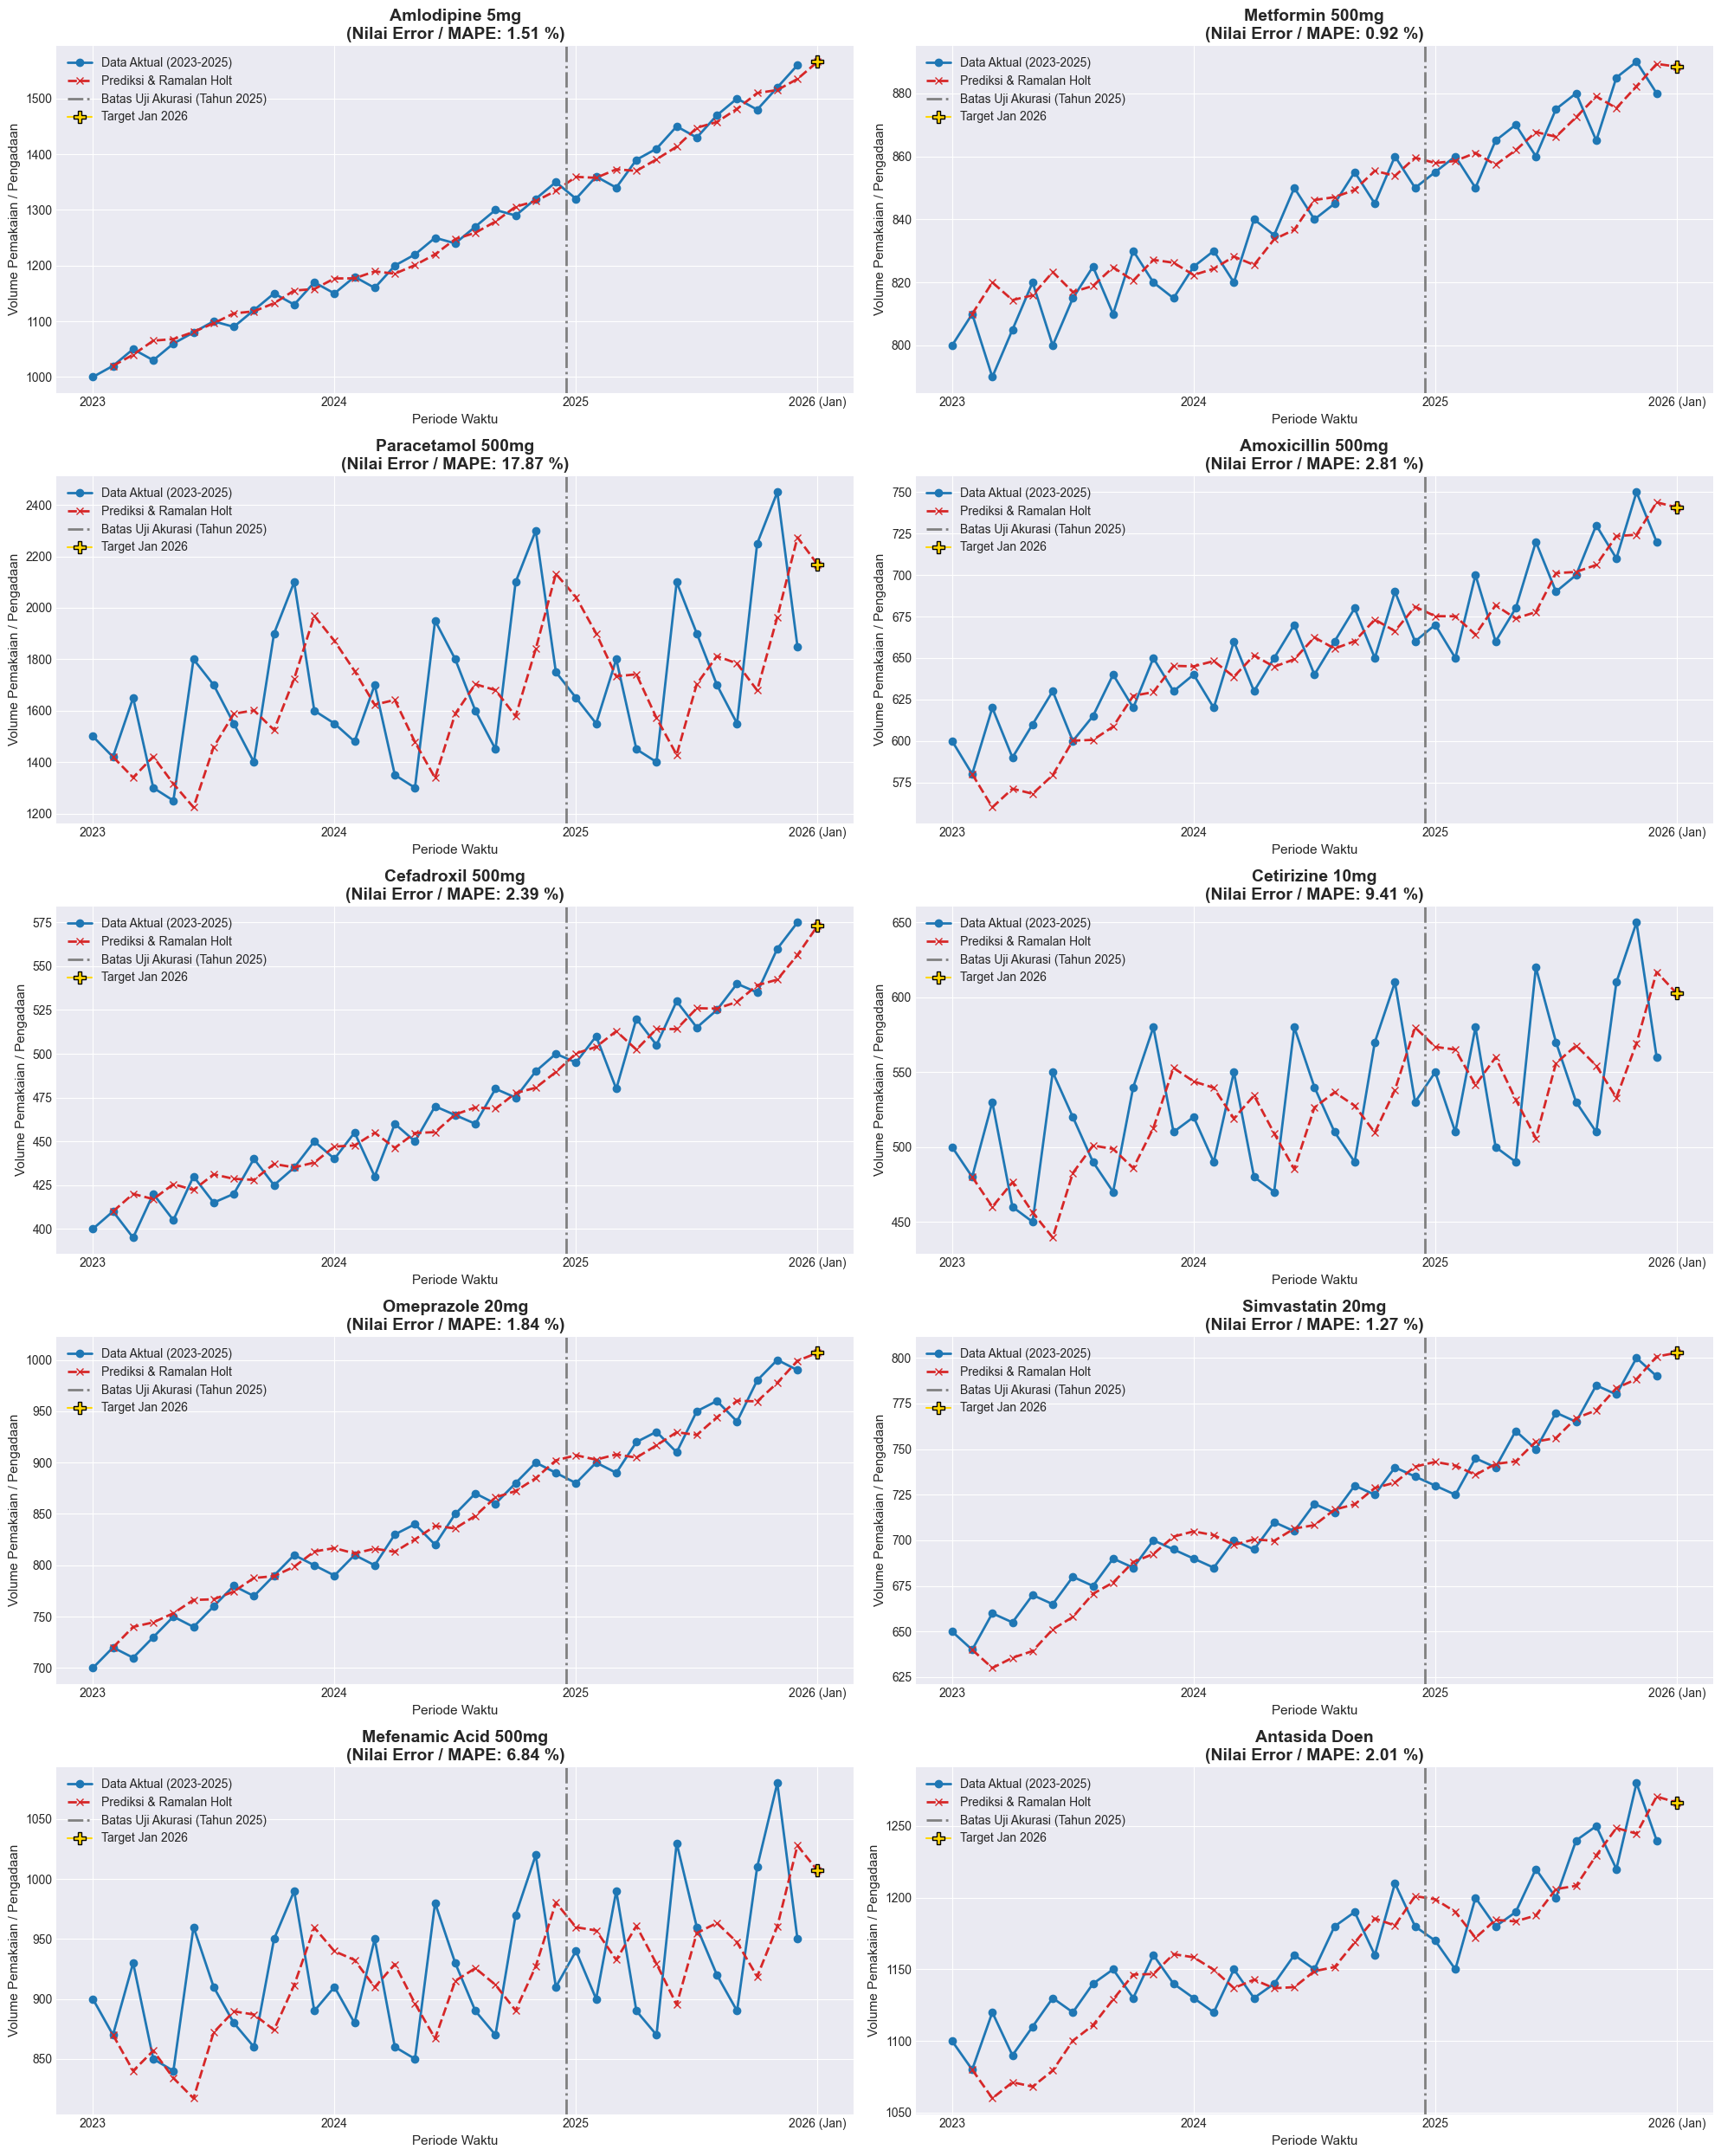

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.flatten()

for i, (obat, data) in enumerate(data_plot.items()):
    ax = axes[i]
    
    # 1. Garis Aktual (Bulan 1 sampai 36)
    ax.plot(range(1, 37), data['aktual'], marker='o', label='Data Aktual (2023-2025)', color='#1f77b4', linewidth=2)
    
    # 2. Garis Prediksi Holt + Peramalan Masa Depan (Bulan 2 sampai 37)
    # Kita ubah range menjadi (2, 38) supaya nilai F[36] (Januari 2026) ikut ter-plot di grafik
    ax.plot(range(2, 38), data['prediksi'][1:], marker='x', linestyle='--', label='Prediksi & Ramalan Holt', color='#d62728', linewidth=2)
    
    # 3. Garis Batas Evaluasi Akurasi (Backtesting 2025)
    ax.axvline(x=24.5, color='gray', linestyle='-.', linewidth=2, label='Batas Uji Akurasi (Tahun 2025)')
    
    # Tambahan: Memberi tanda lingkaran/marker khusus di titik akhir (Bulan 37 / Januari 2026)
    ramalan_2026 = data['prediksi'][36]
    ax.plot(37, ramalan_2026, marker='P', color='gold', markersize=10, markeredgecolor='black', label='Target Jan 2026')
    
    # Pengaturan label grafik
    mape_val = df_hasil[df_hasil['Nama Obat'] == obat]['Nilai MAPE (%)'].values[0]
    ax.set_title(f"{obat}\n(Nilai Error / MAPE: {mape_val} %)", fontsize=14, fontweight='bold')
    
    # Mengubah angka sumbu X menjadi teks label agar lebih informatif seperti gambar contoh
    ax.set_xlabel("Periode Waktu", fontsize=11)
    ax.set_xticks([1, 13, 25, 37])
    ax.set_xticklabels(['2023', '2024', '2025', '2026 (Jan)'])
    
    ax.set_ylabel("Volume Pemakaian / Pengadaan", fontsize=11)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()